Dylan Ross

Make some metadata comparisons

## Setup

### Imports

In [87]:
import os
import itertools

import polars as pl
import numpy as np
from matplotlib import pyplot as plt, rcParams

# set max font size 
rcParams["font.size"] = 8

### Constants

In [2]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures"
)

### Load metadata from cached file

In [3]:
meta = pl.read_ipc(META_CACHE)
meta

Sample,Age,Sex,Race,Study,FLT3_ITD,IDH1+IDH2,NPM1,NRAS
str,f64,str,str,str,bool,bool,bool,bool
"""11-00261""",74.0,"""Male""","""White""","""BeatAML""",true,false,false,false
"""11-00503""",54.0,"""Female""","""White""","""BeatAML""",true,false,true,false
"""11-00475""",65.0,"""Male""","""White""","""BeatAML""",true,false,true,false
"""12-00032""",70.0,"""Male""","""White""","""BeatAML""",true,false,false,false
"""11-00376""",49.0,"""Male""","""White""","""BeatAML""",true,false,true,false
…,…,…,…,…,…,…,…,…
"""16-01109-Bridge""",33.0,"""Male""","""Black""","""pilotStudy""",false,false,false,false
"""16-01191-Bridge""",65.0,"""Female""","""White""","""pilotStudy""",false,false,false,true
"""17-00025-Bridge""",39.0,"""Female""","""White""","""pilotStudy""",true,false,true,false


## Analysis

### Age distributions

In [80]:
def age_boxplot(
    ages_w,
    ages_b,
    figname=None
): 
    # deterministic RNG
    np.random.seed(69420)
    fig, ax = plt.subplots(figsize=(1.2, 2.75))
    point_c = "#AAAAAA"
    ax.plot(
        np.random.normal(1, 0.2, len(ages_b)),
        ages_b,
        marker="v",
        c=point_c,
        ms=1,
        ls="none"
    )
    ax.plot(
        np.random.normal(2, 0.2, len(ages_w)),
        ages_w,
        marker="^",
        c=point_c,
        ms=1,
        ls="none"
    )
    ec = "k"
    ax.boxplot(
        [ages_b, ages_w],
        tick_labels=["Black", "White"],
        widths=0.5,
        showcaps=False,
        showfliers=False,
        boxprops={"c": ec},
        whiskerprops={"c": ec},
        medianprops={"c": ec},
    )
    for d in ["top", "right"]:
        ax.spines[d].set_visible(False)
    ax.set_ylabel("Age")
    if figname is not None:
        plt.savefig(figname, dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()

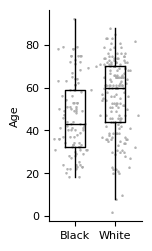

In [81]:
age_boxplot(
    meta.filter(
        (pl.col("Race") == "White")
        & pl.col("Age").is_not_null()
    )["Age"].to_list(),
    meta.filter(
        (pl.col("Race") == "Black")
        & pl.col("Age").is_not_null()
    )["Age"].to_list(),
    figname=os.path.join(FIGURE_DIR, "age_comparison_all.png")
)

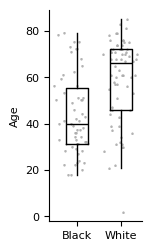

In [86]:
age_boxplot(
    meta.filter(
        (pl.col("Race") == "White")
        & pl.col("Age").is_not_null()
        & ~pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & ~pl.col("NRAS")
    )["Age"].to_list(),
    meta.filter(
        (pl.col("Race") == "Black")
        & pl.col("Age").is_not_null()
        & ~pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & ~pl.col("NRAS")
    )["Age"].to_list(),
    figname=os.path.join(FIGURE_DIR, "age_comparison_WT.png")
)

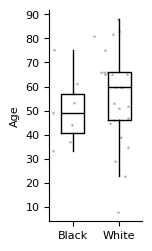

In [84]:
age_boxplot(
    meta.filter(
        (pl.col("Race") == "White")
        & pl.col("Age").is_not_null()
        & pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & ~pl.col("NRAS")
    )["Age"].to_list(),
    meta.filter(
        (pl.col("Race") == "Black")
        & pl.col("Age").is_not_null()
        & pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & ~pl.col("NRAS")
    )["Age"].to_list(),
    figname=os.path.join(FIGURE_DIR, "age_comparison_NPM1.png")
)

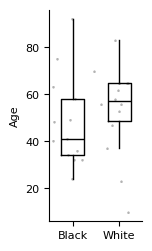

In [85]:
age_boxplot(
    meta.filter(
        (pl.col("Race") == "White")
        & pl.col("Age").is_not_null()
        & ~pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & pl.col("NRAS")
    )["Age"].to_list(),
    meta.filter(
        (pl.col("Race") == "Black")
        & pl.col("Age").is_not_null()
        & ~pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
        & ~pl.col("IDH1+IDH2")
        & pl.col("NRAS")
    )["Age"].to_list(),
    figname=os.path.join(FIGURE_DIR, "age_comparison_NRAS.png")
)

### Sex comparison

In [108]:
def sex_comparison(
    meta,
    figname=None
) : 
    fig, ax = plt.subplots(figsize=(1., 2))

    # colors
    c_white = "w"
    c_black = "k"
    c_border = c_black

    # misc parameters
    w = 0.35            # bar width
    lw = 1              # line width for borders
    r = 0.25            # circle radius
    hatch1 = "OO"     # hatching for F bars
    hatch2 = "xxx"     # hatching for M bars
    split_y = False     # split the y-axis in the top bar plot
    count_pad = 2       # pad the counts up from the tops of the bars by a bit
    muts = {"NPM1", "NRAS"}

    x = 0
    xticks = []
    xticklabels = []
    for n in range(2):
        for true_set in itertools.combinations(muts, n):
            x += 1
            xticks.append(x)
            xticklabels.append("+".join(true_set) if len(true_set) > 0 else "WT")
            false_set = set(muts) - set(true_set)
            # black bars
            f_count = len(
                meta.filter(
                    (pl.col("Sex") == "Female")
                ).filter(
                    pl.all_horizontal(
                        *[pl.col(c) for c in  true_set],
                        *[~pl.col(c) for c in false_set]
                    )
                )
            )
            ax.bar(
                [x], 
                [f_count],
                width=-w,  # align to right edge
                align="edge",
                facecolor=c_white,
                edgecolor=c_border,
                linewidth=lw,
                hatch=hatch1
            )
            # label each bar with the count (if count > 0)
            if f_count > 0:
                ax.text(
                    x - w / 1.5,
                    f_count + count_pad,
                    f_count,
                    va="bottom",
                    ha="center",
                    rotation="vertical",
                    fontsize=6
                )
            # white bars
            m_count = len(
                meta.filter(
                    (pl.col("Sex") == "Male")
                ).filter(
                    pl.all_horizontal(
                        *[pl.col(c) for c in  true_set],
                        *[~pl.col(c) for c in false_set]
                    )
                )
            )
            ax.bar(
                [x], 
                [m_count], 
                width=w,  # align to left edge
                align="edge",
                facecolor=c_white,
                edgecolor=c_border,
                linewidth=lw,
                hatch=hatch2
            )
            # label each bar with the count (for counts > 0)
            if m_count > 0:
                ax.text(
                    x + w / 1.5,
                    m_count + count_pad,
                    m_count,
                    va="bottom",
                    ha="center",
                    rotation="vertical",
                    fontsize=6
                )

    for d in ["top", "right", "left"]:
        ax.spines[d].set_visible(False)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=90)

    if figname is not None:
        plt.savefig(figname, dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()

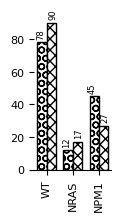

In [109]:
sex_comparison(
    meta,
    figname=os.path.join(FIGURE_DIR, "sex_comparison_all.png")
)

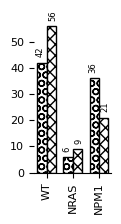

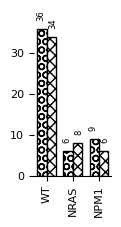

In [111]:
sex_comparison(
    meta.filter(pl.col("Race") == "White"),
    figname=os.path.join(FIGURE_DIR, "sex_comparison_white.png")
)

sex_comparison(
    meta.filter(pl.col("Race") == "Black"),
    figname=os.path.join(FIGURE_DIR, "sex_comparison_black.png")
)